In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'DejaVu Sans Mono'

In [2]:
from data import load_data
from sklearn.impute import KNNImputer, SimpleImputer

df = load_data()
genes = [el for el in df.columns if el.startswith('rs')]
regions = sorted(df['region'].unique())
popls = sorted(df['popl'].unique())

df_chs = []
for ch in 'ACGT':
    df_ch = dict()
    for gene, col in df[genes].iteritems():
        tmp = col.str.count(ch)
        tmp[col == 'NN'] = np.nan
        df_ch[f'{gene}_{ch}'] = tmp
    df_ch = pd.DataFrame(df_ch, dtype=np.float32)
    df_chs.append(df_ch)
df_chs = pd.concat(df_chs, axis=1).sort_index(axis=1)

imputer = SimpleImputer(strategy='mean')
imputer = KNNImputer(n_neighbors=5)
X = imputer.fit_transform(df_chs)

# How distance is distributed

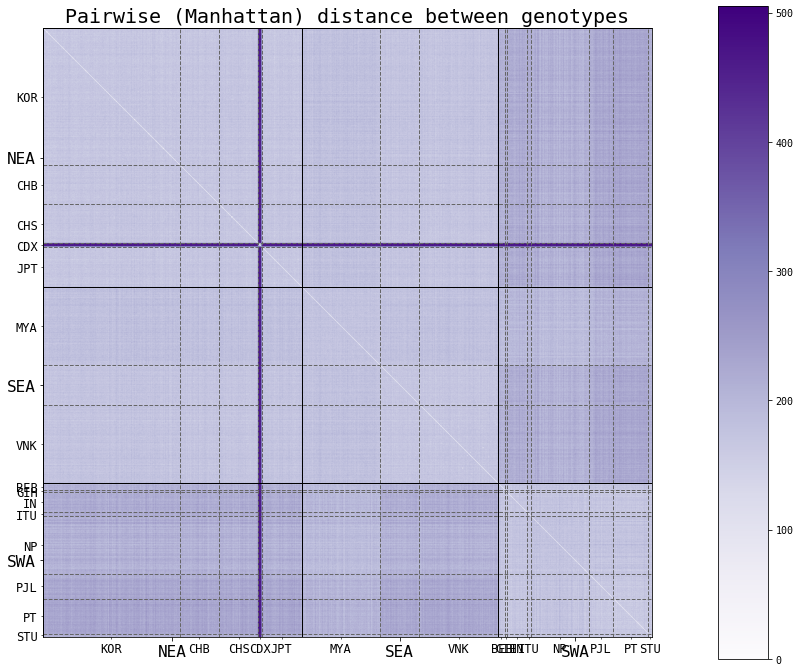

In [3]:
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import LabelEncoder

dist_mat = pairwise_distances(X, metric='manhattan')

region_bdry = np.where(np.diff(LabelEncoder().fit_transform(df['region']), prepend=-1, append=-1) != 0)[0]
popl_bdry = np.where(np.diff(LabelEncoder().fit_transform(df['popl']), prepend=-1, append=-1) != 0)[0]
region_center = (region_bdry[1:] + region_bdry[:-1])/2
popl_center = (popl_bdry[1:] + popl_bdry[:-1])/2

fig, axs = plt.subplots(ncols=2, figsize=(12+1, 12), gridspec_kw={'width_ratios': [12, 1]})
ax = axs[0]
ax_img = ax.imshow(dist_mat, cmap='Purples')
ax.set_xlim(auto=False); ax.set_ylim(auto=False)
for i in popl_bdry:
    ax.axhline(y=i, xmin=0, xmax=1, color='#666666', linewidth=1, linestyle='--')
    ax.axvline(x=i, ymin=0, ymax=1, color='#666666', linewidth=1, linestyle='--')
for i in region_bdry:
    ax.axhline(y=i, xmin=0, xmax=1, color='#000000', linewidth=1)
    ax.axvline(x=i, ymin=0, ymax=1, color='#000000', linewidth=1)
ax.set_xticks(region_center); ax.set_yticks(region_center)
ax.set_xticklabels(df['region'].drop_duplicates(), fontsize=16); ax.set_yticklabels(df['region'].drop_duplicates(), fontsize=16)
ax.set_xticks(popl_center, minor=True); ax.set_yticks(popl_center, minor=True)
ax.set_xticklabels(df['popl'].drop_duplicates(), fontsize=12, minor=True)
ax.set_yticklabels(df['popl'].drop_duplicates(), fontsize=12, minor=True)

ax.set_title('Pairwise (Manhattan) distance between genotypes', fontsize=20)
plt.colorbar(ax_img, cax=axs[1])
plt.show(); plt.close()

## Visualization by UMAP

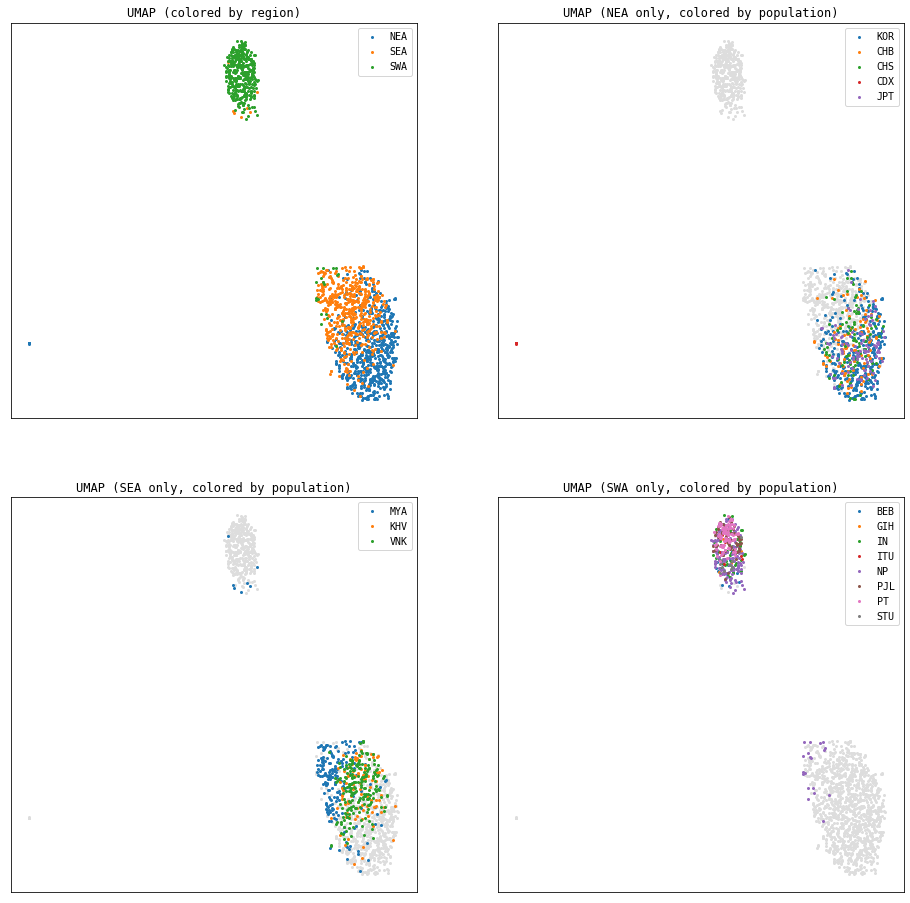

In [4]:
from umap import UMAP
reducer = UMAP(
    n_components=2, 
    metric='manhattan',
    random_state=42
)
X_red = reducer.fit_transform(X)
X_red = pd.DataFrame(X_red, index=df.index)

s = 4.

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(16, 16))

ax = axs[0, 0]
for i, reg in enumerate(regions):
    ax.scatter(*X_red[df['region'] == reg].values.T, color=f'C{i}', s=s, label=reg)  
ax.set_title('UMAP (colored by region)')

ax = axs[0, 1]
ax.scatter(*X_red[df['region'] != 'NEA'].values.T, color='#dddddd', s=s)
for i, pop in enumerate(df.loc[df['region'] == 'NEA', 'popl'].unique()):
    ax.scatter(*X_red[df['popl'] == pop].values.T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (NEA only, colored by population)')

ax = axs[1, 0]
ax.scatter(*X_red[df['region'] != 'SEA'].values.T, color='#dddddd', s=s)
for i, pop in enumerate(df.loc[df['region'] == 'SEA', 'popl'].unique()):
    ax.scatter(*X_red[df['popl'] == pop].values.T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (SEA only, colored by population)')

ax = axs[1, 1]
ax.scatter(*X_red[df['region'] != 'SWA'].values.T, color='#dddddd', s=s)
for i, pop in enumerate(df.loc[df['region'] == 'SWA', 'popl'].unique()):
    ax.scatter(*X_red[df['popl'] == pop].values.T, color=f'C{i}', s=s, label=pop)
ax.set_title('UMAP (SWA only, colored by population)')

for ax in axs.ravel():
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend()
plt.show(); plt.close()

## Some supervised tests

In [8]:
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

model = SVC(C=1.)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['region'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model.fit(X_train, y_train)
print( np.mean(model.predict(X_train) == y_train) )
print(np.mean(model.predict(X_test) == y_test))

0.9449392712550607
0.8802588996763754


In [9]:
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model = KNeighborsClassifier(n_neighbors=25, metric='manhattan')
model.fit(X_train, y_train)
print(np.mean(model.predict(X_train) == y_train))
print(np.mean(model.predict(X_test) == y_test))

0.8445344129554656
0.8090614886731392


c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)
c:\Users\sinwa\AppData\Local\Programs\Python\Python38\lib\site-packages\sklearn\neighbors\_classification.py:211: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, a

## Fuzzy Clustering

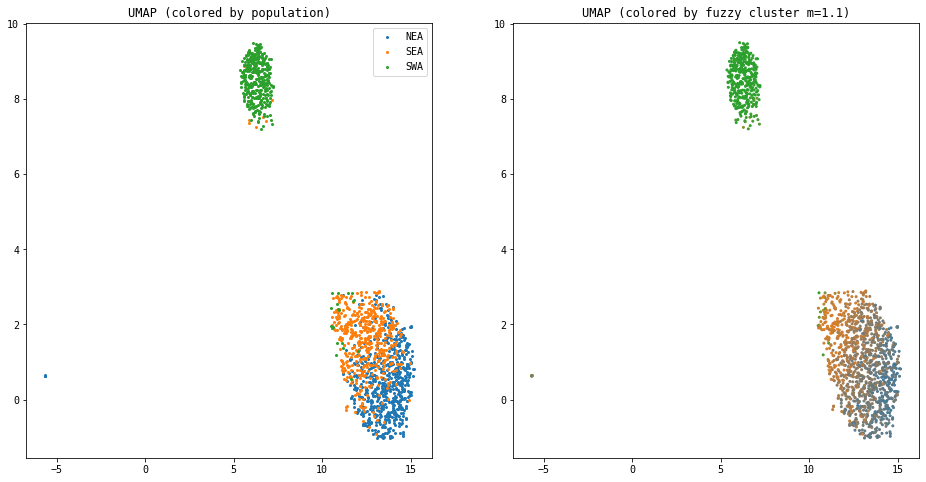

In [14]:
from pyclustering.cluster.fcm import fcm
from matplotlib.colors import to_rgb

m = 1.1

clusterer = fcm(data=X, initial_centers=X[[0, 400, 800]], m=m)
clusterer.process()

default_3 = np.array([to_rgb(c) for c in plt.rcParams['axes.prop_cycle'].by_key()['color'][:3]])

s = 4.

fig, axs = plt.subplots(ncols=2, figsize=(16, 8))
ax = axs[0]
for i, region in enumerate(sorted(df['region'].unique())):
    mask_tmp = (df['region'] == region).values.astype(bool)
    ax.scatter(*X_red[mask_tmp].values.T, s=s, c=f'C{i}', label=region)
ax.legend()
ax.set_title('UMAP (colored by population)')

ax = axs[1]
ax.scatter(*X_red.values.T, s=s, c=clusterer.get_membership() @ default_3[[1, 0, 2]])
ax.set_title(f'UMAP (colored by fuzzy cluster m={m})')

plt.show(); plt.close()

array([2.49085758, 2.47994826, 2.48343484, ..., 1.00003034, 1.00000153,
       1.00000029])

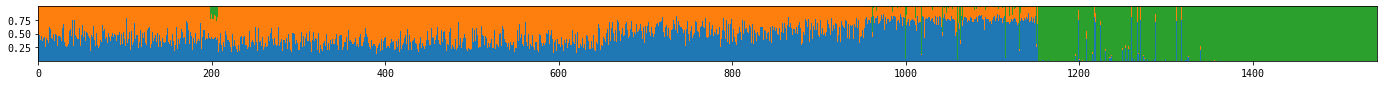

In [36]:
popl_pdf_order = [
    'CHS', 'CHB', 'CDX', 'JPT', 'KOR', 
    'KHV', 'VNK', 'MYA',
    'BEB', 'ITU', 'GIH', 'STU', 'NP', 'IN', 'PJL', 'PT', 'PJ'
]
reindexer = np.concatenate([df.index[df['popl'] == el] for el in popl_pdf_order])

fig, ax = plt.subplots(figsize=(24, 1))
ms_bar = np.array(clusterer.get_membership())[reindexer]
ms_bar = np.concatenate([np.zeros((X.shape[0], 1)), np.cumsum(ms_bar, axis=1)], axis=1)
for i in range(3):
    ax.bar(np.arange(X.shape[0]), ms_bar[:, i+1]-ms_bar[:, i], width=1, bottom=ms_bar[:, i])
ax.set_xlim(0, X.shape[0])
plt.show(); plt.close()